# Loan Approval System — Data Loading, EDA & Preprocessing

Covers: loading the raw dataset, verifying its structure, exploring distributions
and data-quality issues, then cleaning and engineering features into a saved,
reusable preprocessing pipeline for modeling.

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

TARGET = "SeriousDlqin2yrs"

## 1. Load and verify the dataset

In [3]:
df = pd.read_csv("../data/raw/cs-training.csv")
df = df.drop(columns=[df.columns[0]])  # unnamed index column from the CSV export

print("Shape:", df.shape)
df.head()

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_summary[missing_summary["missing_count"] > 0])

                    missing_count  missing_pct
MonthlyIncome               29731        19.82
NumberOfDependents           3924         2.62


In [6]:
target_counts = df[TARGET].value_counts(normalize=True) * 100
print("Target distribution (%):")
print(target_counts.round(2))

Target distribution (%):
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64


### Data-quality checks

Two known issues in this dataset: sentinel/placeholder codes (96, 98) in the
past-due columns, and extreme outlier values in utilization and age.

In [7]:
past_due_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for col in past_due_cols:
    print(f"\n--- {col} : value_counts (tail) ---")
    print(df[col].value_counts().sort_index().tail(10))


--- NumberOfTime30-59DaysPastDueNotWorse : value_counts (tail) ---
NumberOfTime30-59DaysPastDueNotWorse
6     140
7      54
8      25
9      12
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64

--- NumberOfTime60-89DaysPastDueNotWorse : value_counts (tail) ---
NumberOfTime60-89DaysPastDueNotWorse
3     318
4     105
5      34
6      16
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64

--- NumberOfTimes90DaysLate : value_counts (tail) ---
NumberOfTimes90DaysLate
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64


In [8]:
print("Rows with age <= 0:", (df["age"] <= 0).sum())
print("Rows with utilization > 2:", (df["RevolvingUtilizationOfUnsecuredLines"] > 2).sum())
print(df["RevolvingUtilizationOfUnsecuredLines"].describe())

Rows with age <= 0: 1
Rows with utilization > 2: 371
count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


## 2. Exploratory Data Analysis

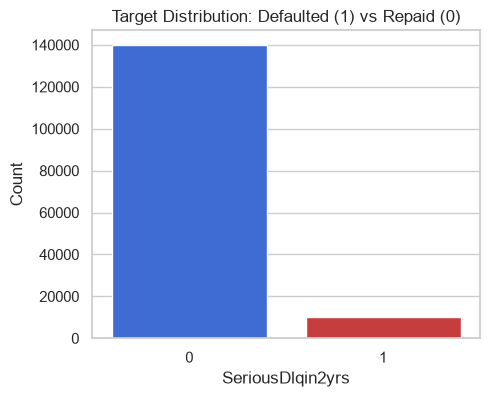

In [9]:
plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET, data=df, hue=TARGET, palette=["#2563EB", "#DC2626"], legend=False)
plt.title("Target Distribution: Defaulted (1) vs Repaid (0)")
plt.xlabel(TARGET); plt.ylabel("Count")
plt.show()

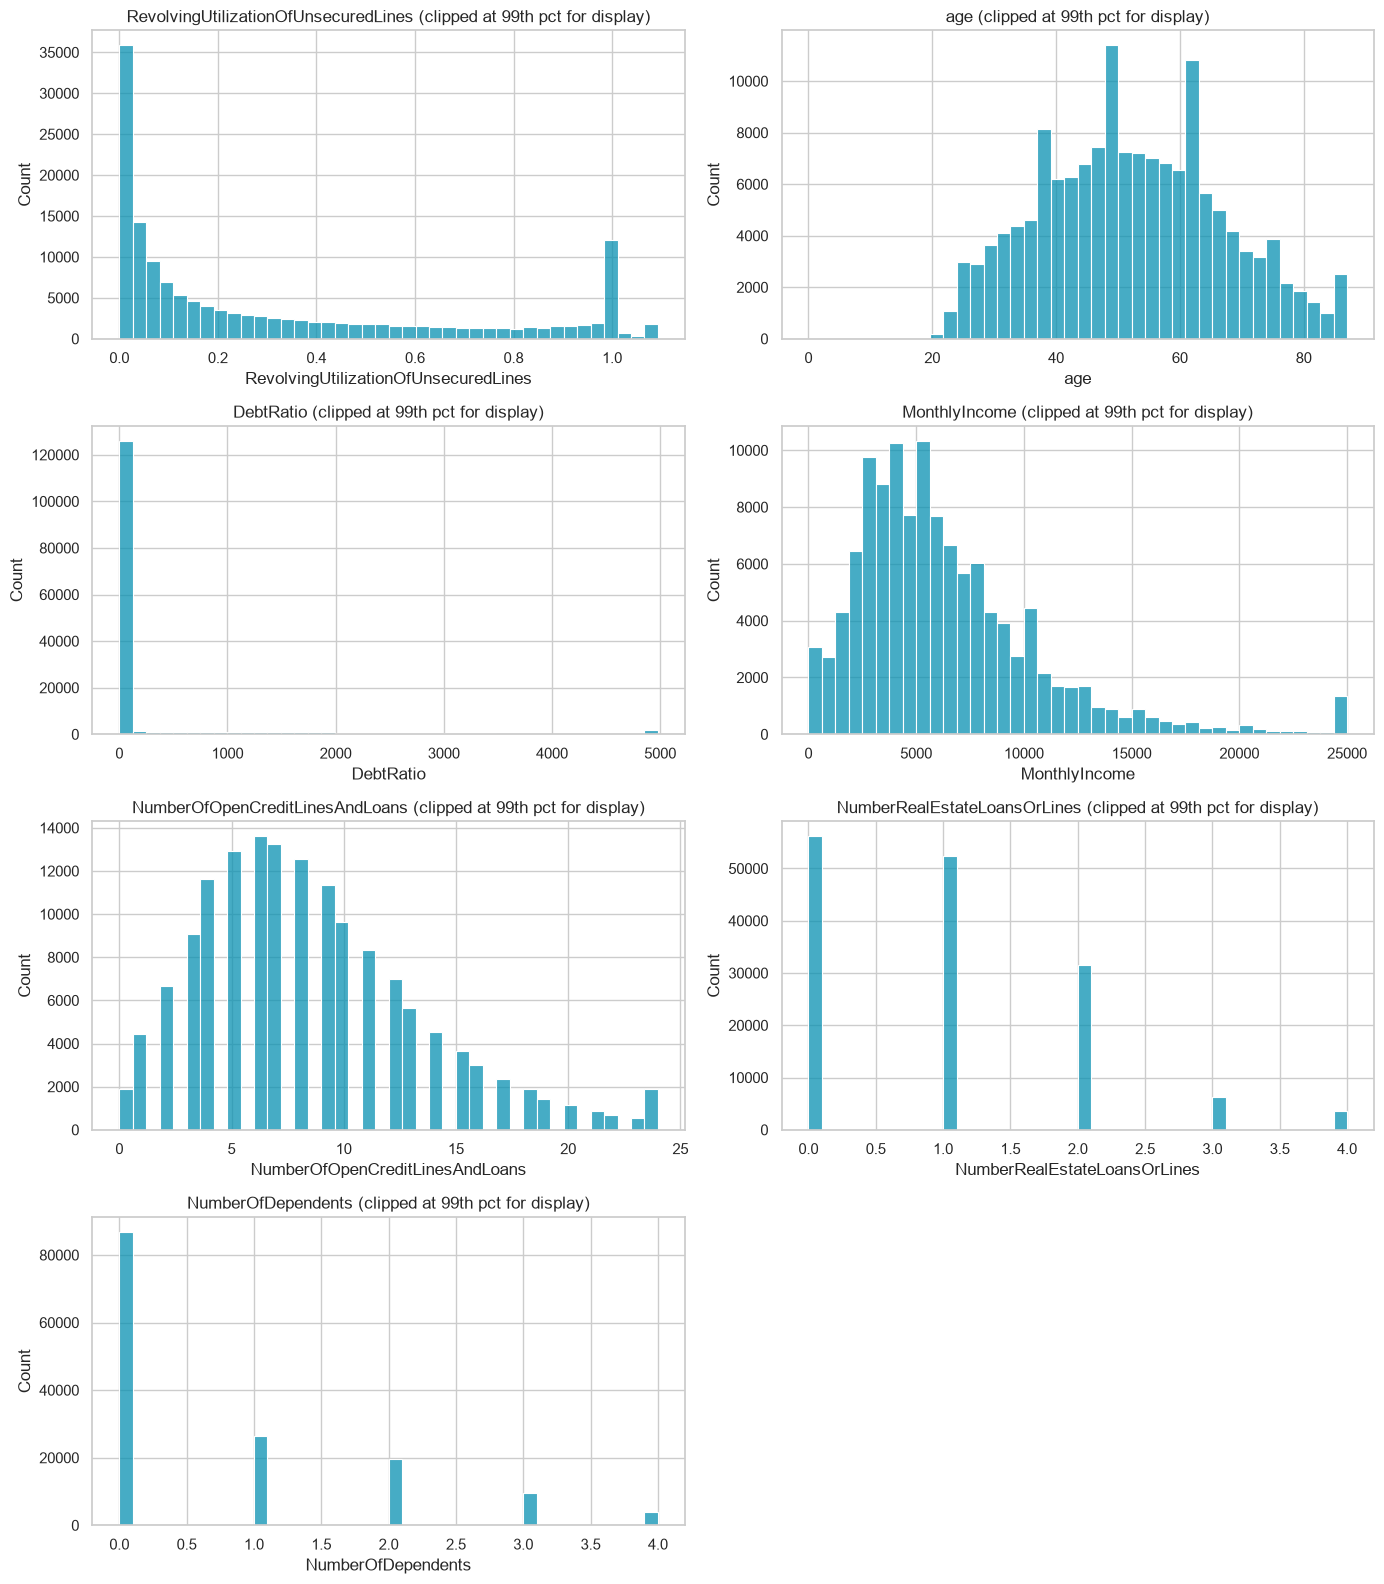

In [10]:
numeric_cols = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines", "NumberOfDependents",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data_to_plot = df[col].clip(upper=df[col].quantile(0.99))  # clipped for display only
    sns.histplot(data_to_plot, bins=40, ax=axes[i], color="#0891B2")
    axes[i].set_title(f"{col} (clipped at 99th pct for display)")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

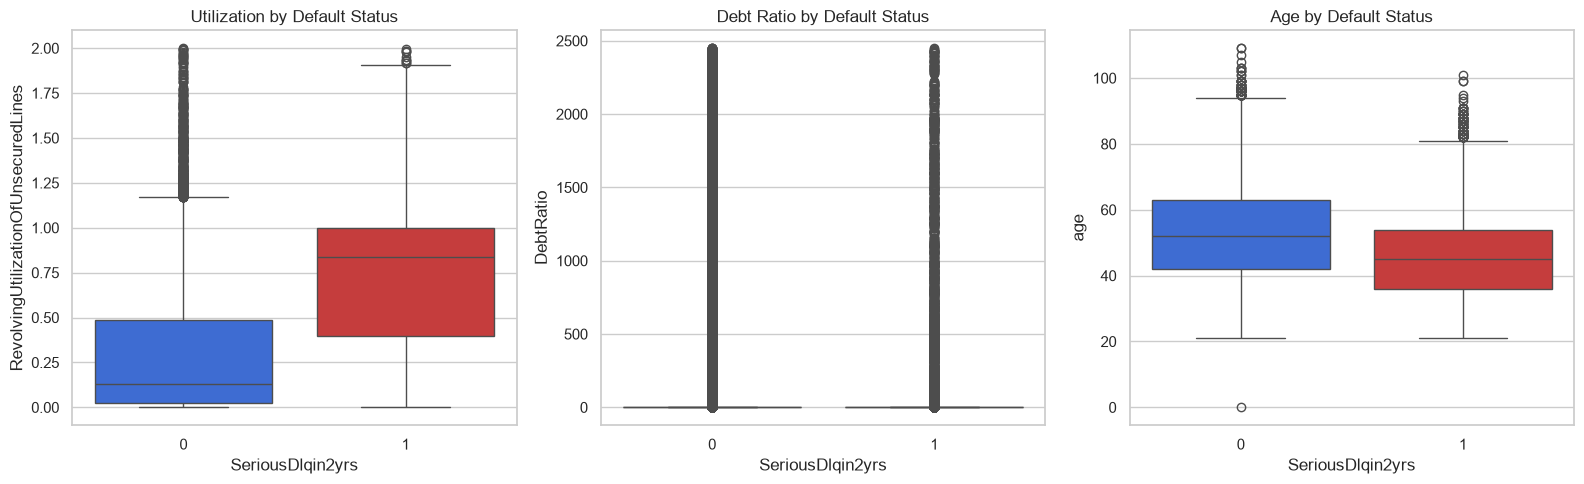

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x=TARGET, y="RevolvingUtilizationOfUnsecuredLines",
            data=df[df["RevolvingUtilizationOfUnsecuredLines"] < 2],
            hue=TARGET, palette=["#2563EB", "#DC2626"], legend=False, ax=axes[0])
axes[0].set_title("Utilization by Default Status")

sns.boxplot(x=TARGET, y="DebtRatio",
            data=df[df["DebtRatio"] < df["DebtRatio"].quantile(0.95)],
            hue=TARGET, palette=["#2563EB", "#DC2626"], legend=False, ax=axes[1])
axes[1].set_title("Debt Ratio by Default Status")

sns.boxplot(x=TARGET, y="age", data=df, hue=TARGET,
            palette=["#2563EB", "#DC2626"], legend=False, ax=axes[2])
axes[2].set_title("Age by Default Status")

plt.tight_layout()
plt.show()

In [12]:
comparison = df.groupby(TARGET)[numeric_cols].mean().T
comparison.columns = ["Repaid (0)", "Defaulted (1)"]
print(comparison.round(3))

                                      Repaid (0)  Defaulted (1)
RevolvingUtilizationOfUnsecuredLines       6.169          4.367
age                                       52.751         45.927
DebtRatio                                357.151        295.121
MonthlyIncome                           6747.838       5630.826
NumberOfOpenCreditLinesAndLoans            8.494          7.882
NumberRealEstateLoansOrLines               1.020          0.989
NumberOfDependents                         0.743          0.948


In [13]:
# Excludes sentinel-code rows just for this check, to see whether past-due
# columns are genuinely predictive once cleaned.
clean_mask = ~(df[past_due_cols] >= 90).any(axis=1)
print(df[clean_mask].groupby(TARGET)[past_due_cols].mean().round(3))

                  NumberOfTime30-59DaysPastDueNotWorse  \
SeriousDlqin2yrs                                         
0                                                0.195   
1                                                0.967   

                  NumberOfTime60-89DaysPastDueNotWorse  \
SeriousDlqin2yrs                                         
0                                                0.041   
1                                                0.398   

                  NumberOfTimes90DaysLate  
SeriousDlqin2yrs                           
0                                   0.050  
1                                   0.665  


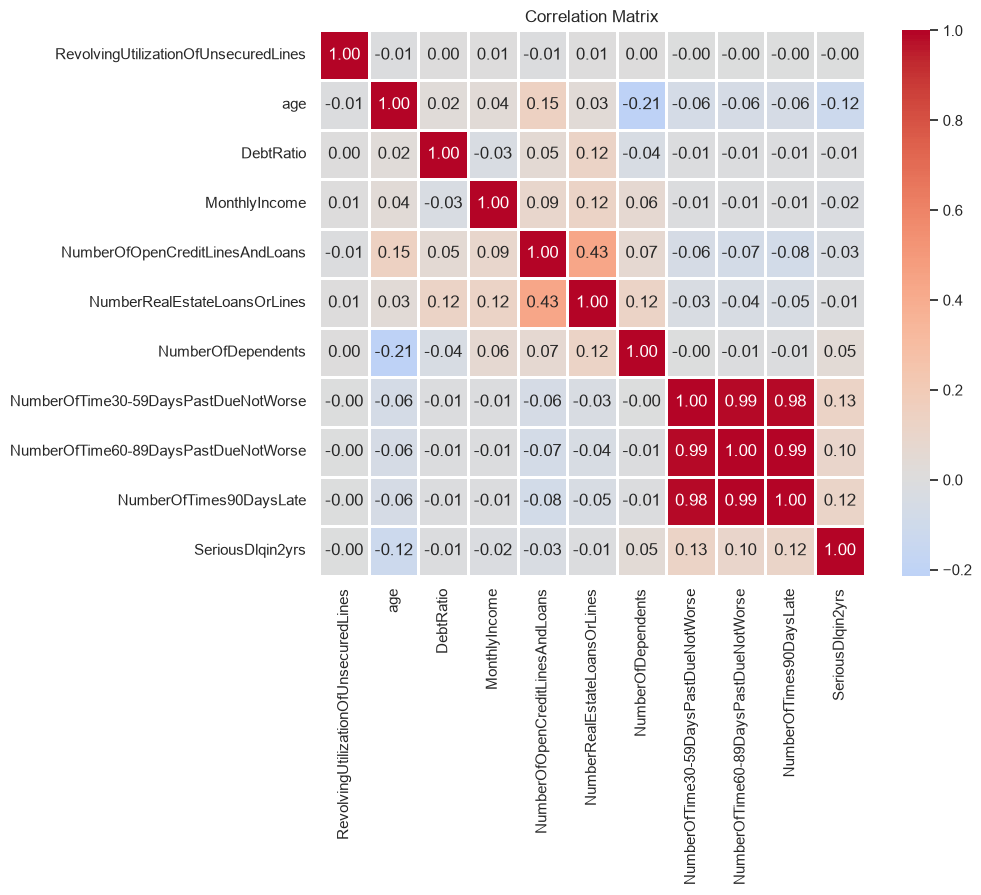

In [15]:
corr_cols = numeric_cols + past_due_cols + [TARGET]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=1.0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
income_missing_flag = df["MonthlyIncome"].isnull().astype(int)
missing_vs_target = df.groupby(income_missing_flag)[TARGET].mean()
print("Default rate by whether MonthlyIncome is missing:")
print(missing_vs_target.round(4))

Default rate by whether MonthlyIncome is missing:
MonthlyIncome
0    0.0695
1    0.0561
Name: SeriousDlqin2yrs, dtype: float64


In [ ]:
df.to_csv("../data/processed/00_loaded.csv", index=False)
print("Checkpoint saved to data/processed/00_loaded.csv")

Checkpoint saved to data/processed/00_loaded.csv


## 3. Preprocessing

In [ ]:
for col in past_due_cols:
    df[col] = df[col].clip(upper=18)   # sentinel codes (96/98) capped, not deleted
print("Sentinel codes capped. New max values:")
print(df[past_due_cols].max())

util_cap = df["RevolvingUtilizationOfUnsecuredLines"].quantile(0.99)
df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=util_cap)
print(f"\nUtilization capped at {util_cap:.2f} (99th percentile)")

df = df[df["age"] > 0].reset_index(drop=True)  # single bad row, not worth imputing
print("Shape after dropping age<=0 row:", df.shape)

Sentinel codes capped. New max values:
NumberOfTime30-59DaysPastDueNotWorse    18
NumberOfTime60-89DaysPastDueNotWorse    18
NumberOfTimes90DaysLate                 18
dtype: int64

Utilization capped at 1.09 (99th percentile)
Shape after dropping age<=0 row: (149999, 11)


### Feature engineering

In [ ]:
df["income_missing"] = df["MonthlyIncome"].isnull().astype(int)
df["dependents_missing"] = df["NumberOfDependents"].isnull().astype(int)

df["monthly_income_filled"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["debt_to_income_ratio"] = df["DebtRatio"] * df["monthly_income_filled"] / (df["monthly_income_filled"] + 1)

df["utilization_bucket"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=[-0.01, 0.3, 0.6, 1.0, np.inf],
    labels=["low", "medium", "high", "over_limit"],
)

df["late_payment_score"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] * 1
    + df["NumberOfTime60-89DaysPastDueNotWorse"] * 2
    + df["NumberOfTimes90DaysLate"] * 3
)

df["dependents_per_income"] = df["NumberOfDependents"].fillna(0) / (df["monthly_income_filled"] + 1)

df["age_bucket"] = pd.cut(
    df["age"], bins=[0, 30, 45, 60, 120],
    labels=["young", "early_career", "mid_career", "senior"],
)

print("Engineered columns added: debt_to_income_ratio, utilization_bucket,",
      "late_payment_score, dependents_per_income, age_bucket")

Engineered columns added: debt_to_income_ratio, utilization_bucket, late_payment_score, dependents_per_income, age_bucket


## 4. Train / validation / test split and the preprocessing pipeline

In [ ]:
numeric_features = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines", "NumberOfDependents",
    "income_missing", "dependents_missing", "debt_to_income_ratio",
    "late_payment_score", "dependents_per_income",
] + past_due_cols
categorical_features = ["utilization_bucket", "age_bucket"]

X = df[numeric_features + categorical_features]
y = df[TARGET]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
    # 0.1765 * 0.85 ≈ 0.15 -> yields ~70/15/15 train/val/test overall
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Default rate — train:", y_train.mean().round(4),
      " val:", y_val.mean().round(4), " test:", y_test.mean().round(4))

Train: (104995, 17)  Val: (22504, 17)  Test: (22500, 17)
Default rate — train: 0.0668  val: 0.0668  test: 0.0668


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# Fit ONLY on training data — val/test are transform-only, preventing leakage.
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)

Processed train shape: (104995, 23)


In [ ]:
joblib.dump(preprocessor, "../models/preprocessor.joblib")
joblib.dump((X_train, X_val, X_test, y_train, y_val, y_test), "../models/splits_raw.joblib")
joblib.dump((X_train_processed, X_val_processed, X_test_processed), "../models/splits_processed.joblib")
print("Saved preprocessor + train/val/test splits to /models")

Saved preprocessor + train/val/test splits to /models
